## Improving Generalization in Deep Learning - Neural Networks

There are many ways we can improve the Neural Network:

1. **Dealing with Noise features**
2. **Random labels to see how the model actually remembers**
3. **Tuning the Learning rate**
4. **L2 regularization**
5. **Dropout - Randomly deactivate neurons**
6. **Early stopping - Stop the training when the accuracy and loss becomes stagnant**

When comparing models, don't just look at the training accuracy and loss. We must also look at the validation accuracy and loss

### Load the MNIST dataset

In [30]:
from tensorflow.keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Vectorize 28x28 image to 784 channels and normalize to [0, 1].
train_images = train_images.reshape((60000, 28 * 28)).astype("float32") / 255.0
test_images = test_images.reshape((10000, 28 * 28)).astype("float32") / 255.0

print("Train Images:", train_images.shape)
print("Test Images:", test_images.shape)

Train Images: (60000, 784)
Test Images: (10000, 784)


### 1. Dealing with Noise features

Noise features are features that do not have any predictive power and can negatively impact the performance of a model. To deal with noise features, we can use techniques such as feature selection, dimensionality reduction, or regularization.

In [31]:
# Here, we only use 20000 images for demonstration
MNIST_SAMPLE_SIZE = 20000

train_images_demo = train_images[:MNIST_SAMPLE_SIZE]
train_labels_demo = train_labels[:MNIST_SAMPLE_SIZE]

print("Shape train_images_demo:", train_images_demo.shape)
print("Shape train_labels_demo:", train_labels_demo.shape)

Shape train_images_demo: (20000, 784)
Shape train_labels_demo: (20000,)


In [32]:
import numpy as np

# Randomize 784 noise channels
noise_channels = np.random.random((len(train_images_demo), 784)).astype("float32")

# Create 784 channels with only zeros
zero_channels = np.zeros((len(train_images_demo), 784), dtype="float32")

# Concatenate original data to noise_channels with axis=1.
train_images_with_noise_channels = np.concatenate([train_images_demo,
                                                   noise_channels], axis=1)

# Concatenate original data to zero_channels with axis=1.
train_images_with_zeros_channels = np.concatenate([train_images_demo,
                                                   zero_channels], axis=1)

print("Data shape with noise channels:", train_images_with_noise_channels.shape)
print("Data shape with zero channels:", train_images_with_zeros_channels.shape)

Data shape with noise channels: (20000, 1568)
Data shape with zero channels: (20000, 1568)


In [33]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the mnist model
def train_mnist_model(input_images):
  input_layer = layers.Input(shape=(input_images.shape[1],))
  hidden_layer1 = layers.Dense(512, activation="relu")
  hidden_layer2 = layers.Dense(256, activation="relu")
  output_layer = layers.Dense(10, activation="softmax")

  model = keras.Sequential([input_layer, hidden_layer1,
                            hidden_layer2, output_layer])

  model.compile(optimizer="rmsprop", loss="sparse_categorical_crossentropy",
                metrics=["accuracy"])

  return model

In [34]:
# Train the model on the data with noise channels
model_with_noise_channels = train_mnist_model(train_images_with_noise_channels)

history_noise = model_with_noise_channels.fit(train_images_with_noise_channels,
                                              train_labels_demo, epochs=10,
                                              batch_size=128, validation_split=0.2, verbose=1)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.6647 - loss: 1.0599 - val_accuracy: 0.8618 - val_loss: 0.4311
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.8549 - loss: 0.4564 - val_accuracy: 0.8462 - val_loss: 0.4807
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9070 - loss: 0.3013 - val_accuracy: 0.7975 - val_loss: 0.6942
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9316 - loss: 0.2163 - val_accuracy: 0.9423 - val_loss: 0.1786
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.9498 - loss: 0.1580 - val_accuracy: 0.9420 - val_loss: 0.1819
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9596 - loss: 0.1278 - val_accuracy: 0.9548 - val_loss: 0.1484
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9698 - loss: 0.0937 - val_accuracy: 0.9525 - val_loss: 0.1685
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.9782 - loss: 0.0703 - val_accu

In [35]:
# Train the model on the data with zero channels
model_with_zeros_channels = train_mnist_model(train_images_with_zeros_channels)

history_zeros = model_with_zeros_channels.fit(train_images_with_zeros_channels,
                                              train_labels_demo, epochs=10,
                                              batch_size=128, validation_split=0.2, verbose=1)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.8617 - loss: 0.4460 - val_accuracy: 0.9337 - val_loss: 0.2108
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9486 - loss: 0.1732 - val_accuracy: 0.9507 - val_loss: 0.1622
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9676 - loss: 0.1065 - val_accuracy: 0.9560 - val_loss: 0.1374
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9776 - loss: 0.0725 - val_accuracy: 0.9640 - val_loss: 0.1170
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9852 - loss: 0.0472 - val_accuracy: 0.9680 - val_loss: 0.1044
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9901 - loss: 0.0333 - val_accuracy: 0.9693 - val_loss: 0.1078
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9926 - loss: 0.0235 - val_accuracy: 0.9703 - val_loss: 0.1027
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9951 - loss: 0.0155 - val_accu

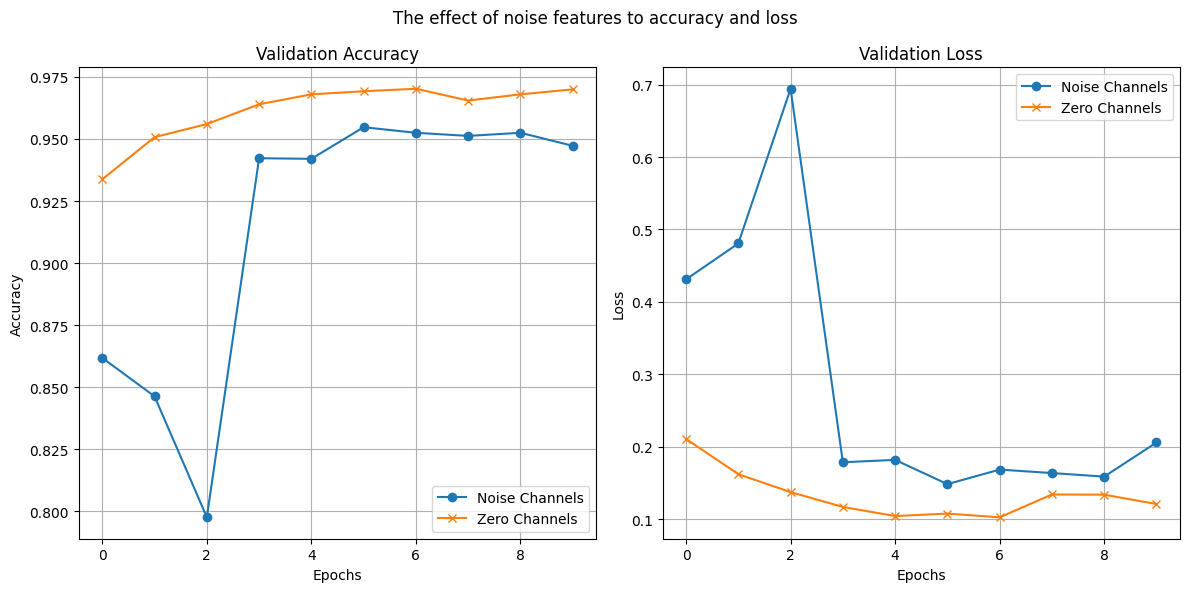

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history_noise.history["val_accuracy"], label="Noise Channels", marker='o')
plt.plot(history_zeros.history["val_accuracy"], label="Zero Channels", marker='x')
plt.title("Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Plot validation loss
plt.subplot(1, 2, 2)
plt.plot(history_noise.history["val_loss"], label="Noise Channels", marker='o')
plt.plot(history_zeros.history["val_loss"], label="Zero Channels", marker='x')
plt.title("Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.suptitle('The effect of noise features to accuracy and loss')
plt.tight_layout()
plt.show()

Based on the plot above, we can see that the data with zero channels obtain better accuracy and loss than the noise data. This is because the noise features are not useful for the model and can lead to overfitting. By removing the noise features, we can improve the generalization of the model and achieve better performance on unseen data.

### 2. Random labels to see how the model actually remembers

Random labels can be used to test the memorization capacity of a model. If a model can achieve high accuracy on random labels, it indicates that the model is overfitting and memorizing the training data rather than learning meaningful patterns. This can be a useful diagnostic tool to assess the generalization ability of a model.

In [37]:
# Create random labels by shuffling the original labels
random_train_labels = train_labels_demo.copy()
np.random.shuffle(random_train_labels)

# Train model with the random labels
model_random_labels = train_mnist_model(train_images_demo)
history_random_labels = model_random_labels.fit(train_images_demo, random_train_labels,
                                                epochs=12, batch_size=128,
                                                validation_split=0.2, verbose=1)

Epoch 1/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.1032 - loss: 2.3134 - val_accuracy: 0.1185 - val_loss: 2.3057
Epoch 2/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.1179 - loss: 2.2972 - val_accuracy: 0.1060 - val_loss: 2.3096
Epoch 3/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.1363 - loss: 2.2834 - val_accuracy: 0.1103 - val_loss: 2.3208
Epoch 4/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.1531 - loss: 2.2637 - val_accuracy: 0.1123 - val_loss: 2.3268
Epoch 5/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.1735 - loss: 2.2312 - val_accuracy: 0.1053 - val_loss: 2.3556
Epoch 6/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.1998 - loss: 2.1898 - val_accuracy: 0.1098 - val_loss: 2.3743
Epoch 7/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.2290 - loss: 2.1353 - val_accuracy: 0.1093 - val_loss: 2.3985
Epoch 8/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.2642 - loss: 2.0676 - val_accu

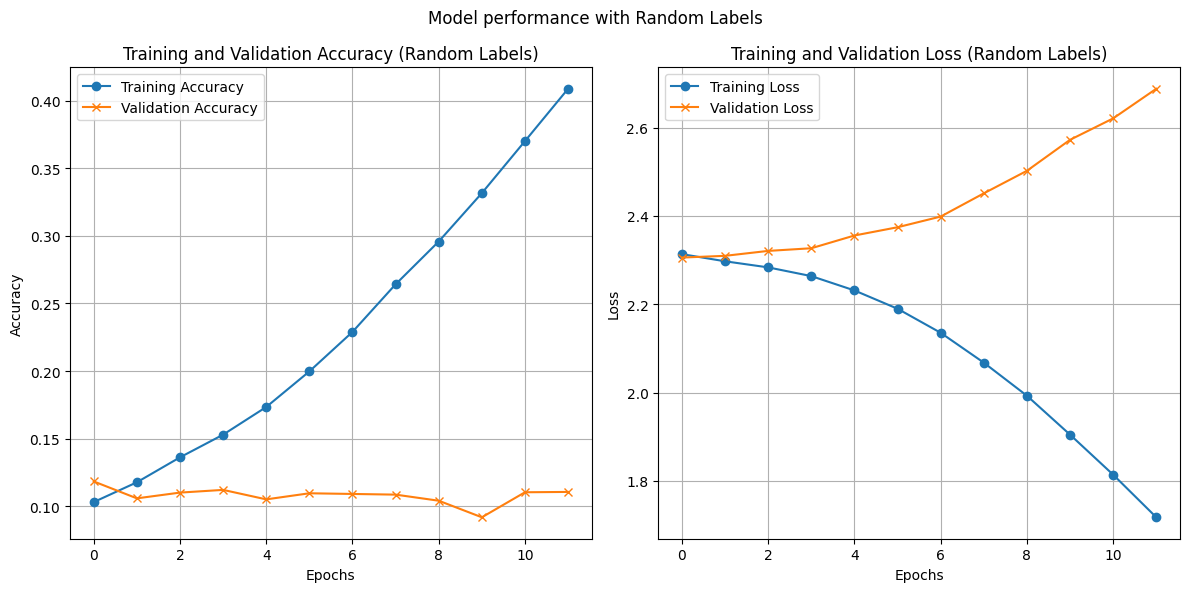

In [38]:
# Plot
plt.figure(figsize=(12, 6))

# Plot training and validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history_random_labels.history["accuracy"], label="Training Accuracy", marker='o')
plt.plot(history_random_labels.history["val_accuracy"], label="Validation Accuracy", marker='x')
plt.title("Training and Validation Accuracy (Random Labels)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history_random_labels.history["loss"], label="Training Loss", marker='o')
plt.plot(history_random_labels.history["val_loss"], label="Validation Loss", marker='x')
plt.title("Training and Validation Loss (Random Labels)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.suptitle('Model performance with Random Labels')
plt.tight_layout()
plt.show()

The accuracy tends to increase but overall, the model is not learning anything meaningful. This is because the random labels do not have any relationship with the input data, and the model is simply memorizing the training examples. This highlights the importance of using meaningful labels and features to train a model that can generalize well to unseen data.

The loss is significantly poor because the model is not learning any meaningful patterns from the data. The random labels do not provide any useful information for the model to learn, and as a result, the loss remains high throughout the training process. This further emphasizes the importance of using meaningful labels and features to train a model that can generalize well to unseen data.

### 3. Tuning the learning rate

Learning rate is a hyperparameter that controls how much the model's weights are updated during training. Tuning the learning rate can help improve the convergence of the model and prevent it from getting stuck in local minima. A learning rate that is too high can cause the model to diverge, while a learning rate that is too low can result in slow convergence. It is important to experiment with different learning rates to find the optimal value for training the model effectively.

In [39]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the mnist model with learning rates
def train_mnist_model_with_lr(input_images, learning_rate):
  input_layer = layers.Input(shape=(input_images.shape[1],))
  hidden_layer1 = layers.Dense(512, activation="relu")
  hidden_layer2 = layers.Dense(256, activation="relu")
  output_layer = layers.Dense(10, activation="softmax")

  model = keras.Sequential([input_layer, hidden_layer1,
                            hidden_layer2, output_layer])

  optimizer = keras.optimizers.RMSprop(learning_rate=learning_rate)
  model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy",
                metrics=["accuracy"])

  return model

In [40]:
# Train with learning rate=1.0
model_lr_1 = train_mnist_model_with_lr(train_images_demo, 1.0)

history_lr_1 = model_lr_1.fit(train_images_demo, train_labels_demo,
                              epochs=10, batch_size=128, validation_split=0.2, verbose=1)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.2422 - loss: 77975.7812 - val_accuracy: 0.1330 - val_loss: 2.6389
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.1223 - loss: 15.4949 - val_accuracy: 0.0997 - val_loss: 6.3326
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.1189 - loss: 91.0502 - val_accuracy: 0.1300 - val_loss: 2.3760
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.1130 - loss: 3.7268 - val_accuracy: 0.0985 - val_loss: 2.4067
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.1028 - loss: 2.4467 - val_accuracy: 0.0950 - val_loss: 2.3807
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.0993 - loss: 2.4604 - val_accuracy: 0.0950 - val_loss: 2.3798
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.1046 - loss: 2.4417 - val_accuracy: 0.0967 - val_loss: 2.4046
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.0999 - loss: 2.4552 - va

In [41]:
# Train with learning rate=1e-2
model_lr_1e2 = train_mnist_model_with_lr(train_images_demo, 1e-2)
history_lr_1e2 = model_lr_1e2.fit(train_images_demo, train_labels_demo,
                                  epochs=10, batch_size=128, validation_split=0.2, verbose=1)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8084 - loss: 1.0525 - val_accuracy: 0.9295 - val_loss: 0.2356
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9356 - loss: 0.2227 - val_accuracy: 0.9400 - val_loss: 0.2239
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9548 - loss: 0.1571 - val_accuracy: 0.9350 - val_loss: 0.2334
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9657 - loss: 0.1241 - val_accuracy: 0.9535 - val_loss: 0.1728
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9726 - loss: 0.1012 - val_accuracy: 0.9470 - val_loss: 0.2233
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9759 - loss: 0.0866 - val_accuracy: 0.9638 - val_loss: 0.1776
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9787 - loss: 0.0799 - val_accuracy: 0.9595 - val_loss: 0.2379
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9804 - loss: 0.0830 - val_accu

In [42]:
# Train with learning rate=1e-3
model_lr_1e3 = train_mnist_model_with_lr(train_images_demo, 1e-3)
history_lr_1e3 = model_lr_1e2.fit(train_images_demo, train_labels_demo,
                                  epochs=10, batch_size=128, validation_split=0.2, verbose=1)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9858 - loss: 0.0584 - val_accuracy: 0.9565 - val_loss: 0.3393
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9866 - loss: 0.0687 - val_accuracy: 0.9613 - val_loss: 0.2577
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9885 - loss: 0.0506 - val_accuracy: 0.9567 - val_loss: 0.3720
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9879 - loss: 0.0611 - val_accuracy: 0.9588 - val_loss: 0.3417
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9908 - loss: 0.0421 - val_accuracy: 0.9630 - val_loss: 0.4612
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9899 - loss: 0.0591 - val_accuracy: 0.9630 - val_loss: 0.3573
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9927 - loss: 0.0443 - val_accuracy: 0.9697 - val_loss: 0.3196
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9909 - loss: 0.0424 - val_accu

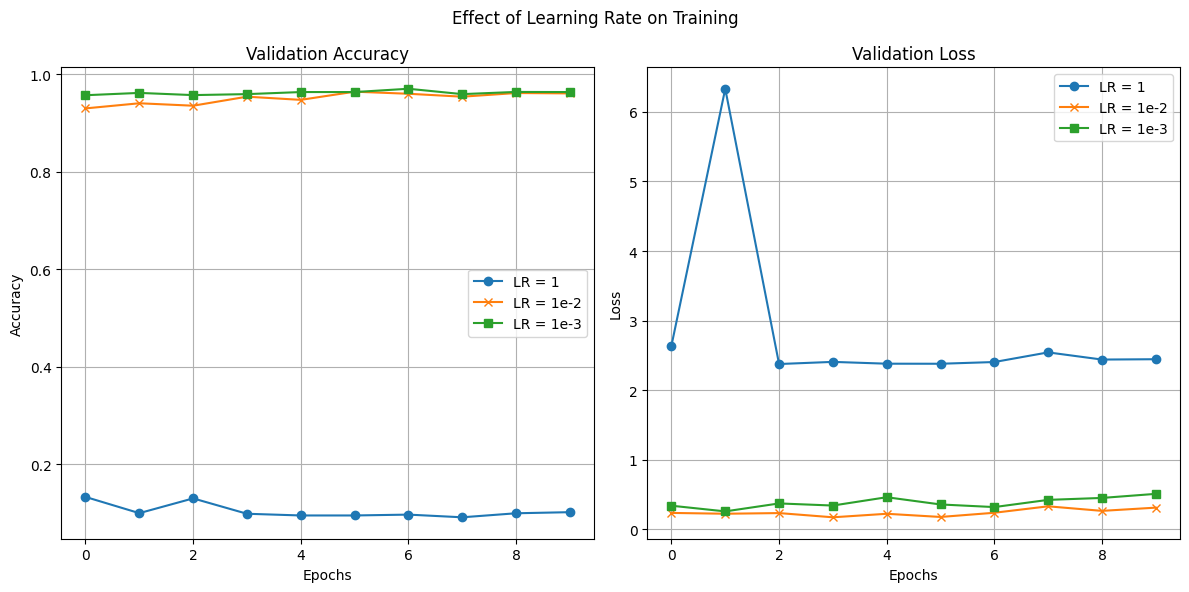

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Validation Accuracy
plt.subplot(1, 2, 1)

plt.plot(history_lr_1.history["val_accuracy"], label="LR = 1", marker='o')
plt.plot(history_lr_1e2.history["val_accuracy"], label="LR = 1e-2", marker='x')
plt.plot(history_lr_1e3.history["val_accuracy"], label="LR = 1e-3", marker='s')
plt.title("Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

# Validation Loss
plt.subplot(1, 2, 2)

plt.plot(history_lr_1.history["val_loss"], label="LR = 1", marker='o')
plt.plot(history_lr_1e2.history["val_loss"], label="LR = 1e-2", marker='x')
plt.plot(history_lr_1e3.history["val_loss"], label="LR = 1e-3", marker='s')

plt.title("Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.suptitle("Effect of Learning Rate on Training")
plt.tight_layout()
plt.show()

Overall, we see that the smaller learning rate has a better accuracy and loss than the larger learning rate. This is because the smaller learning rate allows the model to make more gradual updates to the weights, which can lead to better convergence and improved performance on unseen data. On the other hand, the larger learning rate may cause the model to overshoot the optimal weights, resulting in poor performance and higher loss. Therefore, tuning the learning rate is crucial for achieving good generalization in deep learning models.

But too small learning rate can also lead to slow convergence and may require more epochs to achieve good performance. It is important to find a balance between a learning rate that is too high and too low to ensure efficient training and good generalization.

### 4. L2 regularization

L2 regularization, also known as weight decay, adds a penalty equal to the square of the magnitude of coefficients. This penalty term prevents weights from growing too large, helping to prevent overfitting by making the model simpler.

In [44]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers

# Define the mnist model with L2 regularization
def train_mnist_model_regularization(input_images, l2_strength):
  input_layer = layers.Input(shape=(input_images.shape[1],))
  hidden_layer1 = layers.Dense(512, activation="relu",
                               kernel_regularizer=regularizers.l2(l2_strength))
  hidden_layer2 = layers.Dense(256, activation="relu",
                               kernel_regularizer=regularizers.l2(l2_strength))
  output_layer = layers.Dense(10, activation="softmax")

  model = keras.Sequential([input_layer, hidden_layer1,
                            hidden_layer2, output_layer])

  model.compile(optimizer="rmsprop", loss="sparse_categorical_crossentropy",
                metrics=["accuracy"])

  return model

In [45]:
# Train the model on the data with l2 regularization
model_with_l2 = train_mnist_model_regularization(train_images_demo, 0.002)

history_l2 = model_with_l2.fit(train_images_demo, train_labels_demo,
                               epochs=10, batch_size=128, validation_split=0.2, verbose=1)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.8601 - loss: 1.6134 - val_accuracy: 0.9240 - val_loss: 0.9706
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9337 - loss: 0.7416 - val_accuracy: 0.9165 - val_loss: 0.6673
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9472 - loss: 0.4923 - val_accuracy: 0.9320 - val_loss: 0.4738
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9524 - loss: 0.3859 - val_accuracy: 0.9395 - val_loss: 0.4012
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9581 - loss: 0.3337 - val_accuracy: 0.9525 - val_loss: 0.3277
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9618 - loss: 0.2959 - val_accuracy: 0.9550 - val_loss: 0.3060
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9641 - loss: 0.2717 - val_accuracy: 0.9632 - val_loss: 0.2715
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9687 - loss: 0.2521 - val_accu

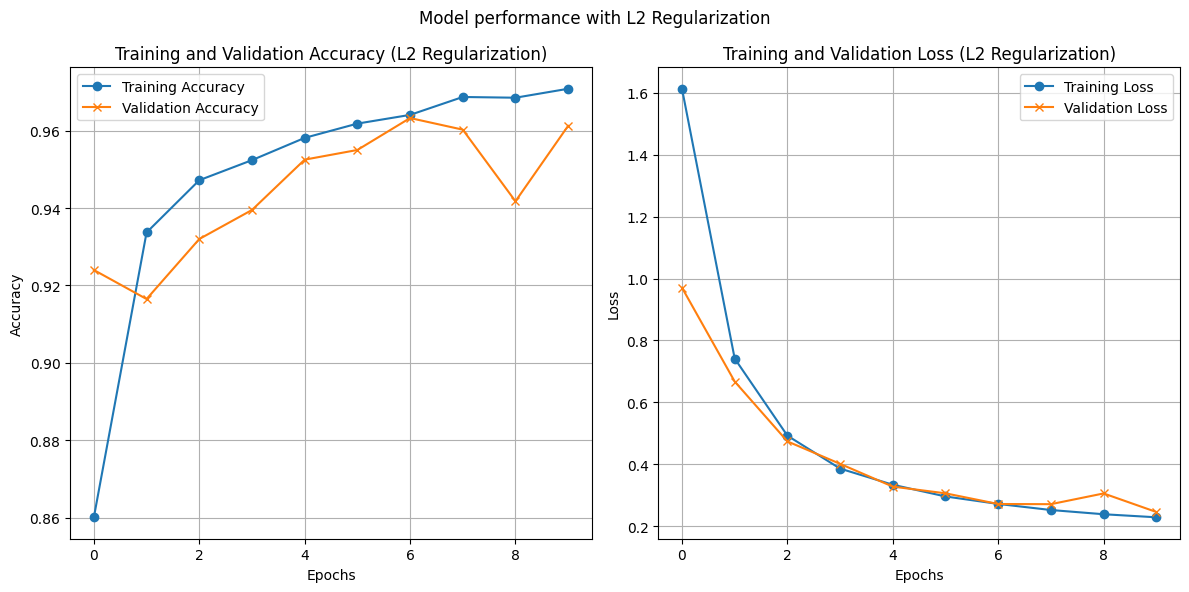

In [46]:
# Plot
plt.figure(figsize=(12, 6))

# Plot training and validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history_l2.history["accuracy"], label="Training Accuracy", marker='o')
plt.plot(history_l2.history["val_accuracy"], label="Validation Accuracy", marker='x')
plt.title("Training and Validation Accuracy (L2 Regularization)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history_l2.history["loss"], label="Training Loss", marker='o')
plt.plot(history_l2.history["val_loss"], label="Validation Loss", marker='x')
plt.title("Training and Validation Loss (L2 Regularization)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.suptitle('Model performance with L2 Regularization')
plt.tight_layout()
plt.show()

By adding L2 regularization, we can encourage the model to learn smaller weights, which can lead to better generalization on unseen data. This is because smaller weights are less likely to overfit the training data and can help the model capture more general patterns in the data.

### 5. Dropout

Dropout is a regularization technique that randomly deactivates a fraction of the neurons during training. This helps to prevent overfitting by forcing the model to learn redundant representations and not rely too heavily on any single neuron.

In [47]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the mnist model with Dropout
def train_mnist_model_with_dropout(input_images, dropout_rate):
  input_layer = layers.Input(shape=(input_images.shape[1],))
  hidden_layer1 = layers.Dense(512, activation="relu")
  dropout_layer1 = layers.Dropout(dropout_rate)
  hidden_layer2 = layers.Dense(256, activation="relu")
  dropout_layer2 = layers.Dropout(dropout_rate)
  output_layer = layers.Dense(10, activation="softmax")

  model = keras.Sequential([input_layer, hidden_layer1, dropout_layer1,
                            hidden_layer2, dropout_layer2, output_layer])

  model.compile(optimizer="rmsprop", loss="sparse_categorical_crossentropy",
                metrics=["accuracy"])

  return model

In [48]:
# Train the model with Dropout
dropout_rate = 0.5
model_with_dropout = train_mnist_model_with_dropout(train_images_demo, dropout_rate)

history_dropout = model_with_dropout.fit(train_images_demo, train_labels_demo,
                                         epochs=20, batch_size=128,
                                         validation_split=0.2, verbose=1)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.7993 - loss: 0.6394 - val_accuracy: 0.9118 - val_loss: 0.2871
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9101 - loss: 0.2992 - val_accuracy: 0.9477 - val_loss: 0.1779
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9326 - loss: 0.2218 - val_accuracy: 0.9565 - val_loss: 0.1477
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9466 - loss: 0.1862 - val_accuracy: 0.9603 - val_loss: 0.1358
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9554 - loss: 0.1503 - val_accuracy: 0.9638 - val_loss: 0.1287
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9594 - loss: 0.1326 - val_accuracy: 0.9645 - val_loss: 0.1231
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9631 - loss: 0.1177 - val_accuracy: 0.9675 - val_loss: 0.1200
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9682 - loss: 0.1007 - val_accu

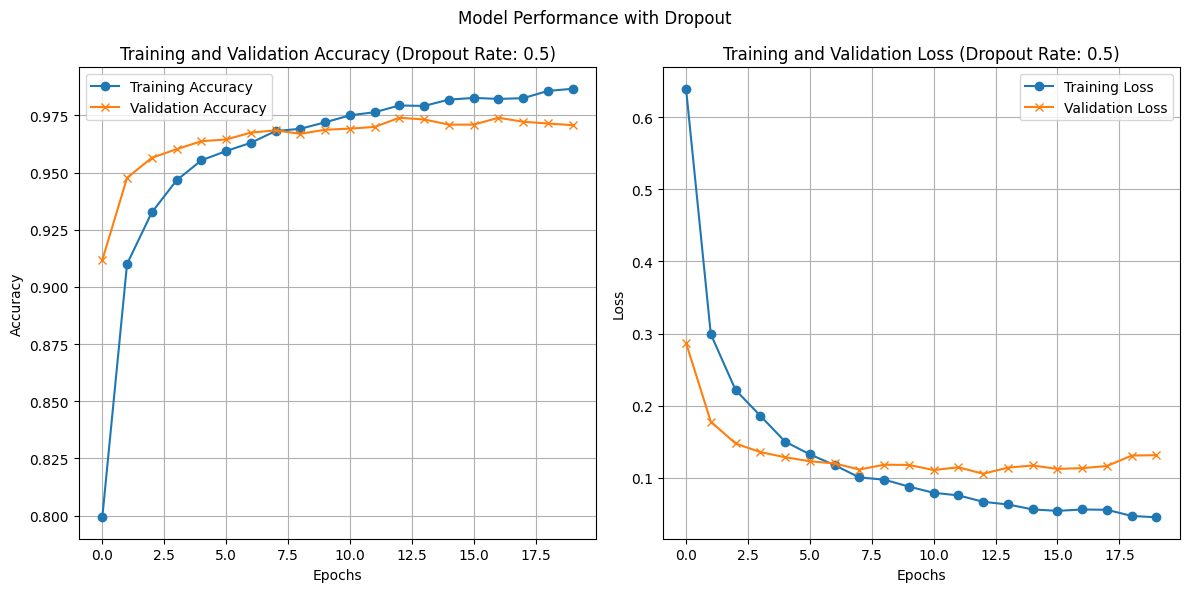

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot training and validation accuracy with Dropout
plt.subplot(1, 2, 1)
plt.plot(history_dropout.history["accuracy"], label="Training Accuracy", marker='o')
plt.plot(history_dropout.history["val_accuracy"], label="Validation Accuracy", marker='x')
plt.title(f"Training and Validation Accuracy (Dropout Rate: {dropout_rate})")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Plot training and validation loss with Dropout
plt.subplot(1, 2, 2)
plt.plot(history_dropout.history["loss"], label="Training Loss", marker='o')
plt.plot(history_dropout.history["val_loss"], label="Validation Loss", marker='x')
plt.title(f"Training and Validation Loss (Dropout Rate: {dropout_rate})")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.suptitle('Model Performance with Dropout')
plt.tight_layout()
plt.show()

Dropout is more suitable for larger models with many parameters, as it can help to reduce overfitting. However, it may not be necessary for smaller models or datasets that are not prone to overfitting. It is important to experiment with different dropout rates to find the optimal value for training the model effectively.

### 6. Early Stopping

Early stopping is a technique that stops the training process when the validation accuracy and loss become stagnant. This helps to prevent overfitting by stopping the training before the model starts to memorize the training data. 

Early stopping can be implemented by monitoring the validation accuracy and loss during training and stopping the training process when the validation accuracy does not improve for a certain number of epochs. This can help to ensure that the model generalizes well to unseen data and does not overfit the training data.

In [50]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# Define the mnist model with Early Stopping
def train_mnist_model_with_early_stopping(input_images, patience):
  input_layer = layers.Input(shape=(input_images.shape[1],))
  hidden_layer1 = layers.Dense(512, activation="relu")
  hidden_layer2 = layers.Dense(256, activation="relu")
  output_layer = layers.Dense(10, activation="softmax")

  model = keras.Sequential([input_layer, hidden_layer1,
                            hidden_layer2, output_layer])

  model.compile(optimizer="rmsprop", loss="sparse_categorical_crossentropy",
                metrics=["accuracy"])

  # Define Early Stopping callback
  early_stopping_callback = EarlyStopping(monitor='val_loss', patience=patience,
                                          restore_best_weights=True, verbose=1)

  history = model.fit(train_images_demo, train_labels_demo,
                      epochs=50, batch_size=128, validation_split=0.2,
                      callbacks=[early_stopping_callback], verbose=1)

  # Get the epoch at which training stopped
  if early_stopping_callback.stopped_epoch > 0:
    stopped_epoch = early_stopping_callback.stopped_epoch
  else:
    stopped_epoch = history.epoch[-1] + 1

  return model, stopped_epoch, history

In [51]:
# Train the model with Early Stopping
patience_value = 5
model_with_early_stopping, stopped_epoch, history_early_stopping = train_mnist_model_with_early_stopping(train_images_demo, patience_value)

print(f"Training stopped at epoch: {stopped_epoch}")

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.8647 - loss: 0.4452 - val_accuracy: 0.9260 - val_loss: 0.2310
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9502 - loss: 0.1690 - val_accuracy: 0.9488 - val_loss: 0.1514
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9678 - loss: 0.1050 - val_accuracy: 0.9603 - val_loss: 0.1342
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9788 - loss: 0.0687 - val_accuracy: 0.9622 - val_loss: 0.1252
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9848 - loss: 0.0478 - val_accuracy: 0.9682 - val_loss: 0.1068
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9908 - loss: 0.0318 - val_accuracy: 0.9657 - val_loss: 0.1161
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9933 - loss: 0.0220 - val_accuracy: 0.9745 - val_loss: 0.1065
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9962 - loss: 0.0139 - val_accu

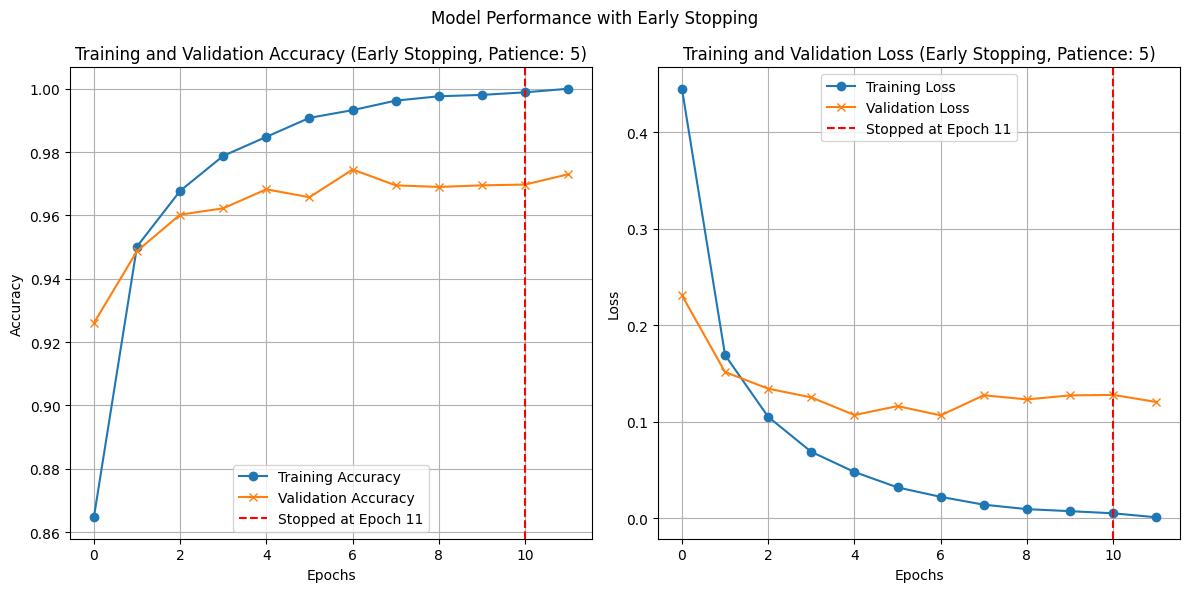

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot training and validation accuracy with Early Stopping
plt.subplot(1, 2, 1)
plt.plot(history_early_stopping.history["accuracy"], label="Training Accuracy", marker='o')
plt.plot(history_early_stopping.history["val_accuracy"], label="Validation Accuracy", marker='x')
plt.axvline(x=stopped_epoch - 1, color='r', linestyle='--', label=f'Stopped at Epoch {stopped_epoch}')
plt.title(f"Training and Validation Accuracy (Early Stopping, Patience: {patience_value})")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Plot training and validation loss with Early Stopping
plt.subplot(1, 2, 2)
plt.plot(history_early_stopping.history["loss"], label="Training Loss", marker='o')
plt.plot(history_early_stopping.history["val_loss"], label="Validation Loss", marker='x')
plt.axvline(x=stopped_epoch - 1, color='r', linestyle='--', label=f'Stopped at Epoch {stopped_epoch}')
plt.title(f"Training and Validation Loss (Early Stopping, Patience: {patience_value})")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.suptitle('Model Performance with Early Stopping')
plt.tight_layout()
plt.show()

With Early Stopping, we can determine the best epoch to stop the training process, which can help to improve the generalization of the model and achieve better performance on unseen data.

In [ ]:
import pandas as pd

# Extract final validation accuracy and loss for each model
results = {
    "Model": [
        "Noise Channels",
        "Zero Channels",
        "Random Labels",
        "Learning Rate = 1.0",
        "Learning Rate = 1e-2",
        "Learning Rate = 1e-3",
        "L2 Regularization",
        "Dropout",
        "Early Stopping"
    ],
    "Final Validation Accuracy": [
        history_noise.history["val_accuracy"][-1],
        history_zeros.history["val_accuracy"][-1],
        history_random_labels.history["val_accuracy"][-1],
        history_lr_1.history["val_accuracy"][-1],
        history_lr_1e2.history["val_accuracy"][-1],
        history_lr_1e3.history["val_accuracy"][-1],
        history_l2.history["val_accuracy"][-1],
        history_dropout.history["val_accuracy"][-1],
        history_early_stopping.history["val_accuracy"][-1]
    ],
    "Final Validation Loss": [
        history_noise.history["val_loss"][-1],
        history_zeros.history["val_loss"][-1],
        history_random_labels.history["val_loss"][-1],
        history_lr_1.history["val_loss"][-1],
        history_lr_1e2.history["val_loss"][-1],
        history_lr_1e3.history["val_loss"][-1],
        history_l2.history["val_loss"][-1],
        history_dropout.history["val_loss"][-1],
        history_early_stopping.history["val_loss"][-1]
    ]
}

# Create a pandas DataFrame
df_results = pd.DataFrame(results)

# Display the table
df_results.round(4)

,Model,Final Validation Accuracy,Final Validation Loss
0,Noise Channels,0.9473,0.2059
1,Zero Channels,0.9700,0.1210
2,Random Labels,0.1107,2.6881
3,Learning Rate = 1.0,0.1018,2.4450
4,Learning Rate = 1e-2,0.9603,0.3115
5,Learning Rate = 1e-3,0.9630,0.5096
6,L2 Regularization,0.9613,0.2457
7,Dropout,0.9707,0.1315
8,Early Stopping,0.9730,0.1204


Overall, these techniques can help to improve the generalization of deep learning models and achieve better performance on unseen data. It is important to experiment with different combinations of these techniques to find the optimal configuration for training the model effectively.